# Predictia bazata pe regresie

In aceasta parte dorim sa prezicem un set de valori continue pentru a prezice *temperatura resimtita de om* in functie de niste paratmetrii relevanti.
De ce temperatura resimtita de om? Deoarece ar fi inutil sa prezicem temperatura actuala pe baza unor parametrii tot actuali, deci trebuie sa fie si ei masurati, nu ne bazam pe trecut.In plus, temperatura resimtita nu poate fi masurata direct cu un instrument simplu, spre deosebire de temperatura actuala.

Dataset-ul contine masuratori facute de un senzor in orasul Szeged, masuratori de :
- umiditate
- viteza vantului
- presiune
- temperatura
- vizibilitate
- si informatii despre cum este vremea, in cuvinte. Pentru aceasta parte vom folosi encodare pentru a trece din domeniul cuvintelor in domeniul numeric.
- si cel mai probabil coloanele de tipul summary care nu aduc informatie relevanta vor fi eliminata.Ma refer la summary, deoarece este o scurta descriere despre toate masuratorile, iar noi nu avem cum sa cunoastem summary inainte de predictie.
Dataset-ul se regaseste la link-ul : https://www.kaggle.com/datasets/budincsevity/szeged-weather/data

De ce am ales sa prezic asta?
Mi se pare un domeniu interesant care se bazeaza mult pe probabilitati si predictii.

Astfel, in urma acestui notebook, vom afla top 5 modele de ML care prezic cel mai bun rezultat.
- **Coloana tinta (y)**:  — temperatura resimtita(C)
- **Coloanele input (X)**: restul coloanelor care ofera date relevante.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
%load_ext autoreload
%autoreload 2

df = pd.read_csv('../Datasets/weatherHistory.csv')
df.shape


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(96453, 12)

La prima vedere par multe linii, suficiente pentru un model de Machine Learning.

In [4]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='str')

Putem observa parametrii(coloanele).

In [5]:
df.dtypes

Formatted Date                  str
Summary                         str
Precip Type                     str
Temperature (C)             float64
Apparent Temperature (C)    float64
Humidity                    float64
Wind Speed (km/h)           float64
Wind Bearing (degrees)      float64
Visibility (km)             float64
Loud Cover                  float64
Pressure (millibars)        float64
Daily Summary                   str
dtype: object

Multe date sunt numere, float, ceea ce ne poate ajuta. Probabil ne vom folosi de tipul de precipitatie care este de tipul string. In principiu, nu vom face predictia in functie de data, deoarece ar fi mai complicat si din restul parametrii ne putem da seama aproximativ in ce perioada a anului suntem.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(8), str(4)
memory usage: 16.3 MB


Cum arata dataset-ul:

In [8]:
df.head(5)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


## Analiza calitativă:

In [9]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

Observam ca in dataset, majoritatea tipului de precipitatie este ploaie sau ninsoare. In urma la EDA, daca acest atribut nu influenteaza cu mult putem sa il eliminam cu totul. Daca influenteaza, unde este null putem pune, de exemplu "none", nu exista precipitatii.

## Analiza statistică:

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature (C),96453.0,11.932678,9.551546,-21.822222,4.688889,12.0000,18.838889,39.905556
Apparent Temperature (C),96453.0,10.855029,10.696847,-27.716667,2.311111,12.0000,18.838889,39.344444
Humidity,96453.0,0.734899,0.195473,0.000000,0.600000,0.7800,0.890000,1.000000
Wind Speed (km/h),96453.0,10.810640,6.913571,0.000000,5.828200,9.9659,14.135800,63.852600
Wind Bearing (degrees),96453.0,187.509232,107.383428,0.000000,116.000000,180.0000,290.000000,359.000000
Visibility (km),96453.0,10.347325,4.192123,0.000000,8.339800,10.0464,14.812000,16.100000
Loud Cover,96453.0,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Pressure (millibars),96453.0,1003.235956,116.969906,0.000000,1011.900000,1016.4500,1021.090000,1046.380000


Observam ca _Loud Cover_ are doar valoarea 0, ceea ce inseamna ca nu aduce vreo influenta in predictie, astfel il vom elimina.
Deviatia standart este destul de mare sau acceptabila la majoritatea, ceea ce inseamna ca datele sunt imprastiate, acoperind multe exemple.

In [11]:
df.skew(numeric_only=True)

Temperature (C)             0.094127
Apparent Temperature (C)   -0.057302
Humidity                   -0.715880
Wind Speed (km/h)           1.113493
Wind Bearing (degrees)     -0.154643
Visibility (km)            -0.498712
Loud Cover                  0.000000
Pressure (millibars)       -8.422506
dtype: float64

Exista la multe asimetrice negativa fata de medie.

## Analiză univariată
In aceasta parte dorim sa vedem cum se comporta fiecare variabila in parte, ce valori are, cum influenteaza rezultatul final, daca exista anumite relatii recurente intre variabila si rezultat.
Vom analiza prin grafice, numaram rezulatele, histograme.

In [12]:
df["Apparent Temperature (C)"].value_counts()

Apparent Temperature (C)
12.777778    378
17.777778    373
13.888889    342
17.222222    330
12.222222    305
            ... 
19.438889      1
31.533333      1
9.588889       1
9.738889       1
9.233333       1
Name: count, Length: 8984, dtype: int64

Variaza foarte mult tipul de temperatura resimtita, de la negative la pozitive foarte mari. Totusi cele inalte sunt putine, fiind aproximativ cate una. Majoritatea temperaturilor indica anotimpul de primavara sau toamna.

<Axes: xlabel='Apparent Temperature (C)', ylabel='Count'>

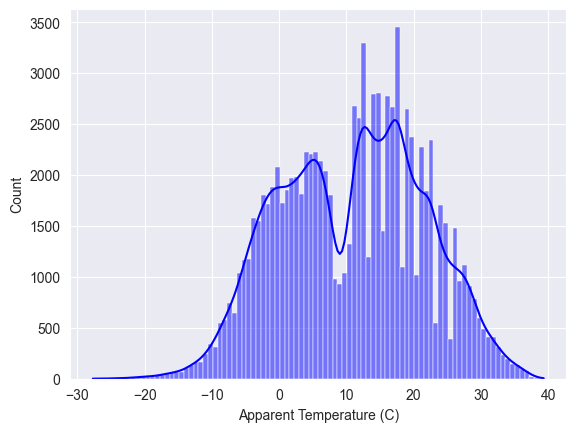

In [14]:
sns.histplot(data=df,x='Apparent Temperature (C)',kde=True, color='Blue')

In analiza temperaturii resimtite observam 2 punte ce maxim local, ceea ce indica clar 2 tipuri de anotimpuri masurate.

<Axes: xlabel='Temperature (C)', ylabel='Count'>

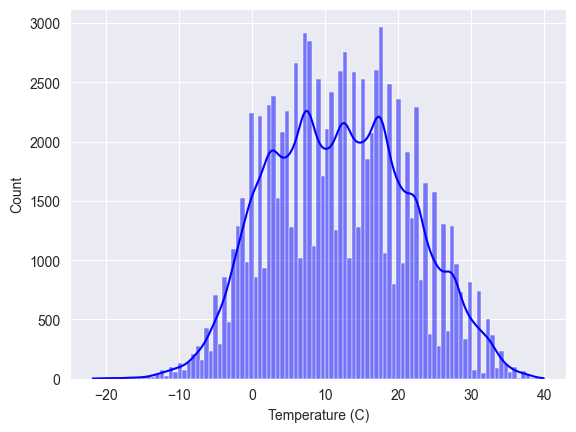

In [15]:
sns.histplot(data=df,x='Temperature (C)',kde=True, color='Blue')

Temperatura masurata nu are "2 cocoase", majoritatea valorilor sunt intre 0 si 20 de grade Celsius. Exista fluctuatii, dar mici, cand au loc peste 2000 de masuratori.

<Axes: xlabel='Apparent Temperature (C)'>

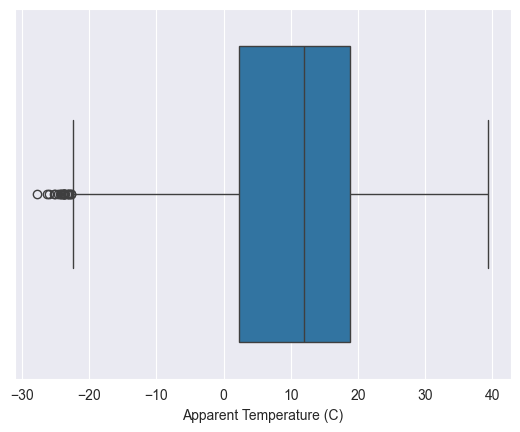

In [16]:
sns.boxplot(data=df, x='Apparent Temperature (C)' )

Mai sus putem observa distributia temperaturii resimtite. Exista outliers in special la temperaturi extreme negative. Majoritatea temperaturilor, cum am putut observa mai sus, se situeaza in jurul mediei de 10-15 grade. Minimum este putin sub -20 de grade si maximum de aproape 40 de grade. Probabil sunt masuratori din toate anotimpurile, dar din vara si iarna foarte putine. Sau exista erori grave a senzorului.

<Axes: xlabel='Temperature (C)'>

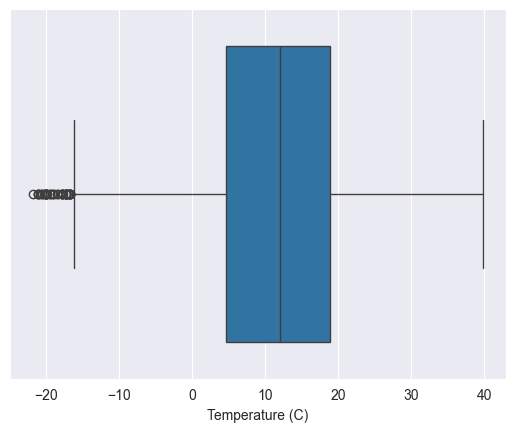

In [17]:
sns.boxplot(data=df, x='Temperature (C)' )

Temperatura masurata seamana cu cea anterior analizata, insa minimul este mai mare si outliers sunt in aceeasi zona, dar cu valori mai mari. Majoritatea masuratorilor tot in acea zona se regasesc si mediana este aproximativ in aceeasi situatie, putin peste 10 grade celsius.

<Axes: xlabel='Humidity'>

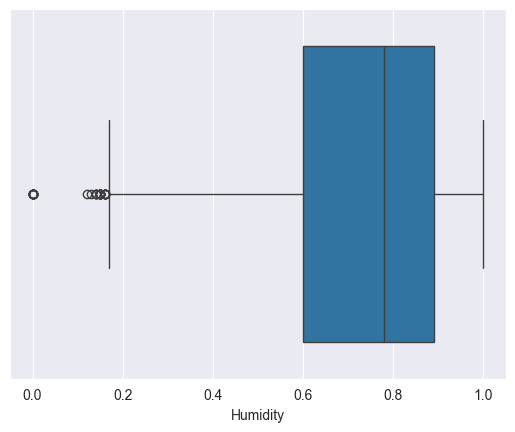

In [18]:
sns.boxplot(data=df, x='Humidity' )

Majoritatea datelor sunt concentrate intre 0.6 si 1.0 — umiditate relativ ridicata.Mediana e in jurul lui 0.7.Sunt prezenti cativa outlieri cu valori foarte scazute (aproape de 0), insa acestia reprezinta cazuri rare si nu sunt imposibili fizic,

<Axes: xlabel='Humidity', ylabel='Density'>

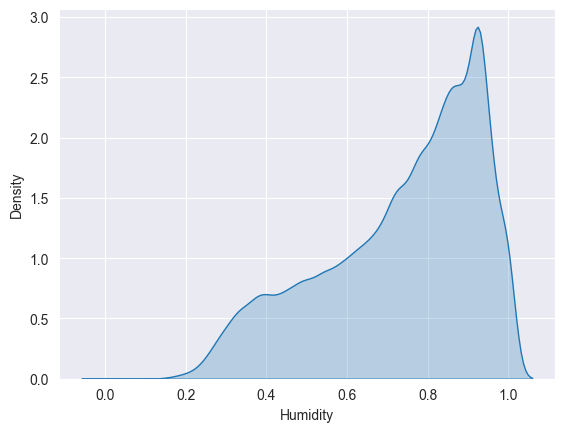

In [19]:
sns.kdeplot(data=df, x='Humidity', fill=True)

Distributia umiditatii este asimetrica la stanga, cel mai probabil din cauza outliers vazuti anterior.

## Analiza bivariată și multivariată
In acest pas dorim sa vedem relatiile dintre aceste dintre variabile, mai ales sub forma de grafic. Cum se comporta aceste variabile, sa analizam daca exista relatii matematice intre ele, de exemplu sa fie o relatie liniara.

Un prim pas ar fi sa vedem coeficientii de corelatie intre variabile( cine influenteaza pe cine cel mai mult).

In [21]:
df.corr(numeric_only=True)

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
Temperature (C),1.000000,0.992629,-0.632255,0.008957,0.029988,0.392847,NaN,-0.005447
Apparent Temperature (C),0.992629,1.000000,-0.602571,-0.056650,0.029031,0.381718,NaN,-0.000219
Humidity,-0.632255,-0.602571,1.000000,-0.224951,0.000735,-0.369173,NaN,0.005454
Wind Speed (km/h),0.008957,-0.056650,-0.224951,1.000000,0.103822,0.100749,NaN,-0.049263
Wind Bearing (degrees),0.029988,0.029031,0.000735,0.103822,1.000000,0.047594,NaN,-0.011651
Visibility (km),0.392847,0.381718,-0.369173,0.100749,0.047594,1.000000,NaN,0.059818
Loud Cover,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pressure (millibars),-0.005447,-0.000219,0.005454,-0.049263,-0.011651,0.059818,NaN,1.000000


Pentru temperatura aparenta exista o relatie puternica intre temperatura masurata(ceea ce era de asteptat), umiditate si vizibilitate.

In [22]:
df[['Apparent Temperature (C)', 'Humidity']].corr()

,Apparent Temperature (C),Humidity
Apparent Temperature (C),1.000000,-0.602571
Humidity,-0.602571,1.000000


O reprezentare vizuala a acestor relatii intre coeficienti:

<Axes: >

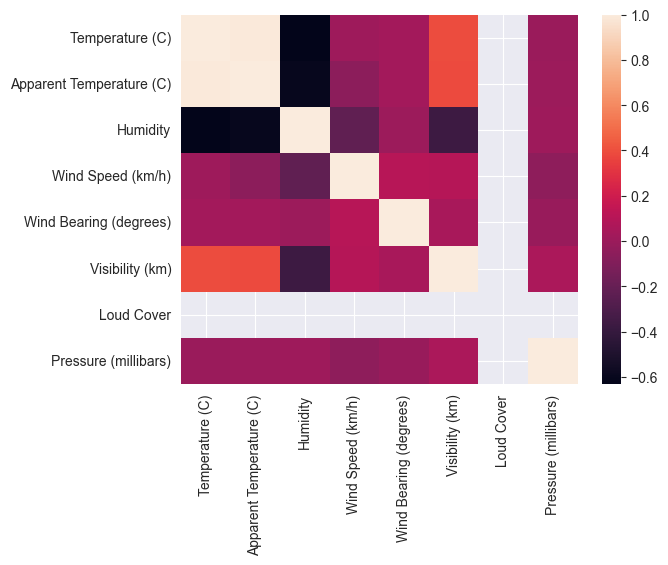

In [23]:
sns.heatmap(df.corr(numeric_only=True))

In acest heatmap se poate observa ce am analizat anterior. De mentionat ca umiditatea are o relatie negativa(inversa) cu temperatura.

<Axes: xlabel='Humidity', ylabel='Apparent Temperature (C)'>

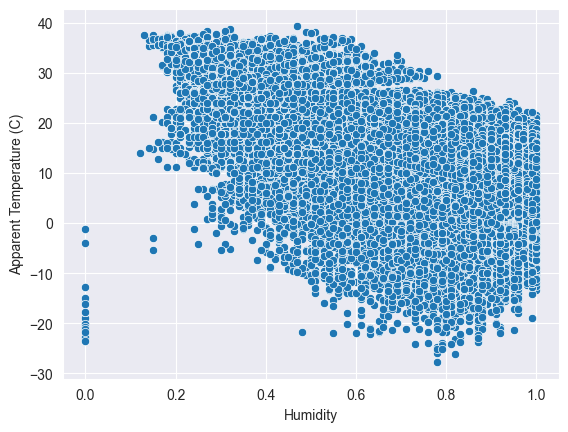

In [24]:
sns.scatterplot(data=df, x='Humidity', y='Apparent Temperature (C)')


<Axes: xlabel='Humidity', ylabel='Temperature (C)'>

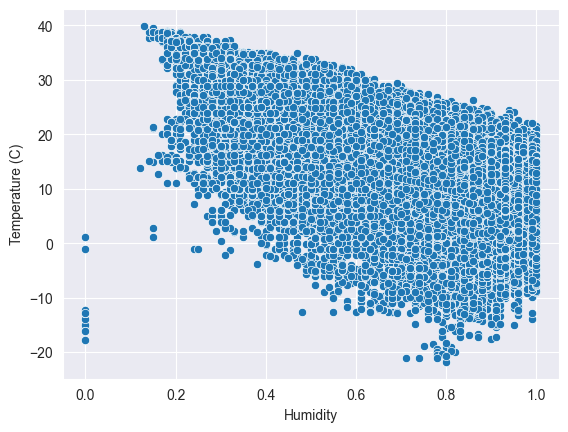

In [25]:
sns.scatterplot(data=df, x='Humidity', y='Temperature (C)')


<Axes: xlabel='Temperature (C)', ylabel='Apparent Temperature (C)'>

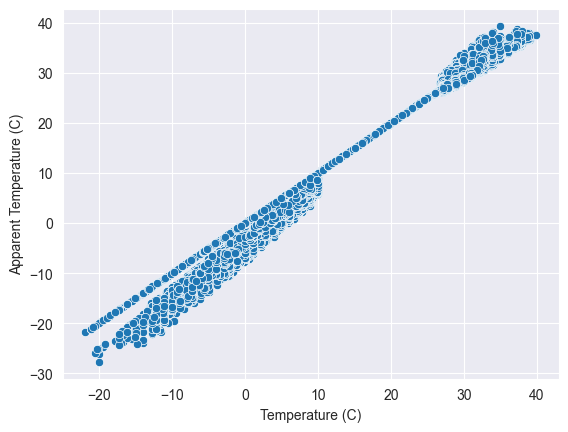

In [30]:
sns.scatterplot(data=df, x='Temperature (C)', y='Apparent Temperature (C)')


<Axes: xlabel='Humidity', ylabel='Visibility (km)'>

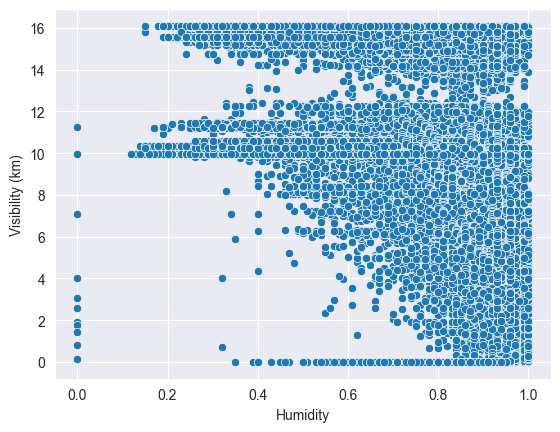

In [32]:
sns.scatterplot(data=df, y='Visibility (km)', x='Humidity')


<Axes: xlabel='Visibility (km)', ylabel='Apparent Temperature (C)'>

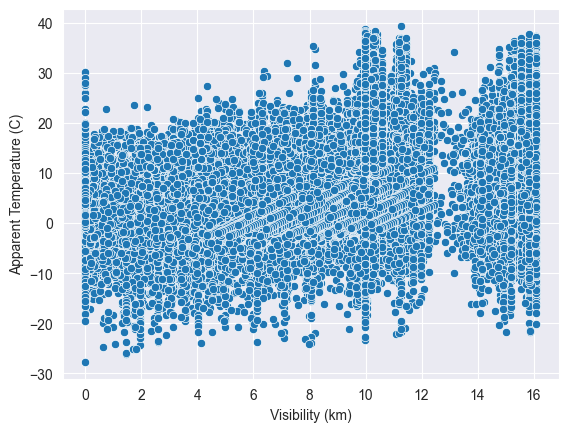

In [28]:
sns.scatterplot(data=df, x='Visibility (km)', y='Apparent Temperature (C)')


Putem observa o relatie liniara intre temperatura masurata si cea actuala, cele 2 fiind direct proportionale.
In plus, poate ar exista o relatie usoara intre umiditate si vizibilitate, poate de grupare , dar nu ne putem da seama foarte mare, deoarece este o densitate de date foarte mare.

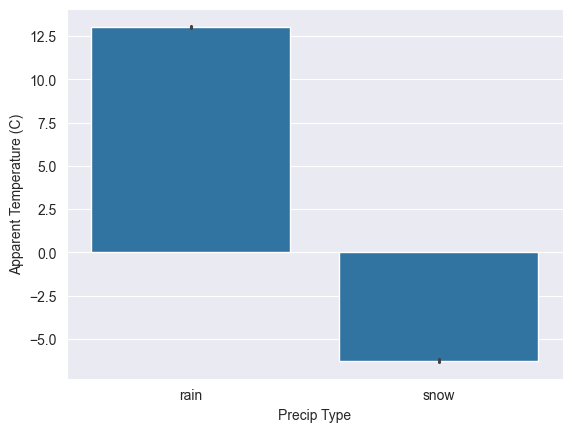

In [33]:
sns.barplot(data=df, x='Precip Type', y='Apparent Temperature (C)')
plt.show()

Mai sus putem vedea faptul ca acest dataset este normal oarecum, deoarece temperaturile sunt mai ridicate cand ploua fata de perioada cu zapada.

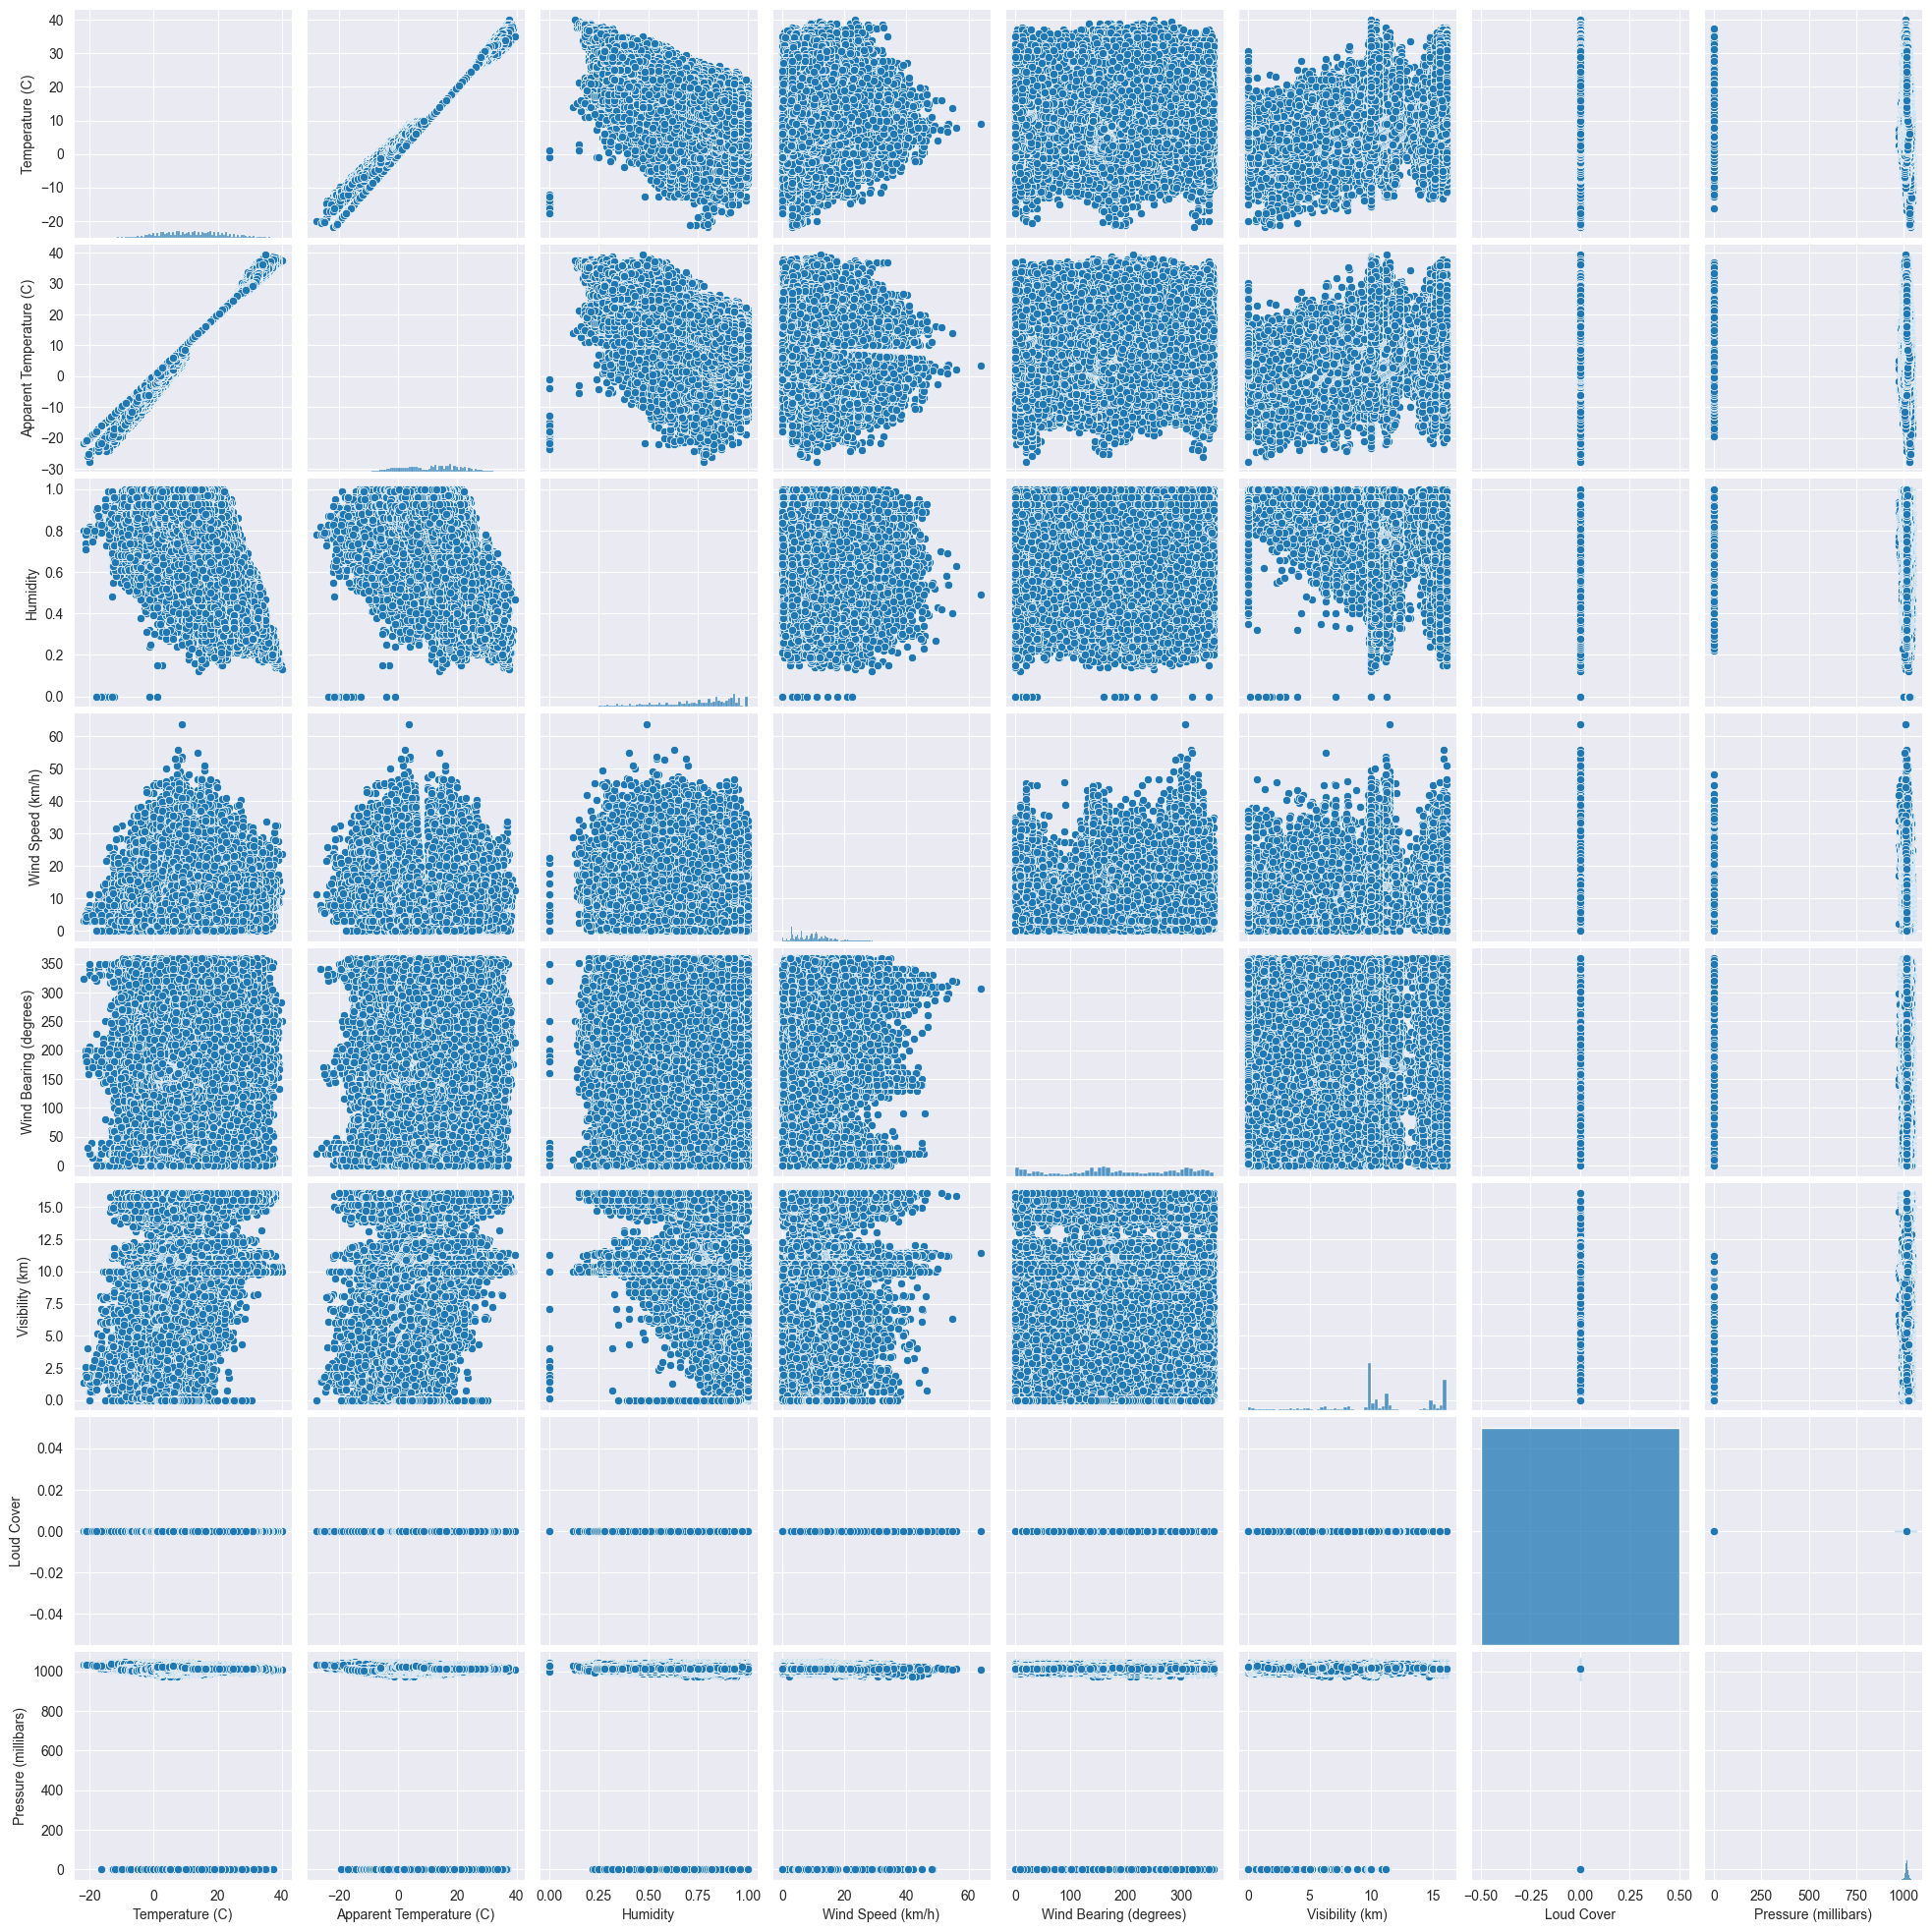

In [34]:
sns.pairplot(df)
plt.show()

Partea de Loud cover este irelevanta. In plus, presiunea atmososferica influenteaza mult prea putin orice alt parametru. Pe langa relatiile discutate anterior, se observa o usoara liniaritate intre umiditate si temperatura, dar cu o eroare reziduala mai mare.Oarecum se grupeaza toate rezultatele catre o directie.Deci sigur, un rol important il va acea senzorul de masurare a temperaturii reale.

## Curățarea și corectarea datelor